# Set GPU

In [1]:
import os

# You can only use one GPU at a time
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"

In [2]:
%%bash
echo "CUDA_VISIBLE_DEVICES: $CUDA_VISIBLE_DEVICES"
echo "OMP_NUM_THREADS: $OMP_NUM_THREADS"
echo "MKL_NUM_THREADS: $MKL_NUM_THREADS"

CUDA_VISIBLE_DEVICES: 0
OMP_NUM_THREADS: 16
MKL_NUM_THREADS: 16


In [3]:
import torch

if torch.cuda.is_available():
    torch.cuda.set_device(0)

    print("CUDA is available.")
    print(f"Number of CUDA devices: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA is not available.")

CUDA is available.
Number of CUDA devices: 1
Current device: 0
Device name: NVIDIA A100-PCIE-40GB


In [4]:
import torch
import torchvision.transforms as transforms
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.datasets.folder import default_loader
import os
from datetime import datetime

# Load Model

In [5]:
# Load your model checkpoint
from vv.models.latent_diffusion_copy.vq_model import VQModel
model_ckpt = "./models/VQ_GAN_f16_256_1024_1_pretrained/last.ckpt"
#model_ckpt = "./models/VQ_256_512_32/version_0/checkpoints/epoch=22-step=1880000-val/total_loss=0.2359.ckpt"

model_args = {
    "learning_rate": 4.5e-06,
    "embed_dim": 256,
    "n_embed": 1024,
    "num_spaces": 32,
    "split_quantizer": False,
    "monitor": "val/rec_loss",
    "ddconfig": {
        "double_z": False,
        "z_channels": 256,
        "resolution": 256,
        "in_channels": 3,
        "out_ch": 3,
        "ch": 128,
        "ch_mult": [1, 1, 2, 2, 4],
        "num_res_blocks": 2,
        "attn_resolutions": [16],
        "dropout": 0.0,
    },
    "lossconfig": {
        "target": "vv.models.latent_diffusion_copy.loss.VQLPIPSWithDiscriminator",
        "params": {
            "disc_conditional": False,
            "disc_in_channels": 3,
            "disc_num_layers": 3,
            "disc_start": 1,
            "disc_weight": 0.8,
            "codebook_weight": 1.0,
        },
    },
}

# Initialize model with required arguments
model = VQModel(**model_args)

# Load checkpoint (ignore missing/mismatched keys if necessary)
checkpoint = torch.load(model_ckpt, map_location="cuda")

# Load state_dict safely
blap = model.load_state_dict(checkpoint["state_dict"], strict=False)

# Move to GPU and set to eval mode
model = model.cuda().eval()

print("Model successfully loaded!")

making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels


./venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
./venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth
VQLPIPSWithDiscriminator running with hinge loss.
Model successfully loaded!


In [6]:
#_IncompatibleKeys(missing_keys=['vq_standard.embedding.weight', 'vq_split.embedding.weight', 'vq_split.embeddings.0.weight'], unexpected_keys=[]) is normal due to backwards compatibility adjustment
blap

_IncompatibleKeys(missing_keys=['vq_standard.embedding.weight', 'vq_split.embedding.weight', 'vq_split.embeddings.0.weight', 'vq_split.embeddings.1.weight', 'vq_split.embeddings.2.weight', 'vq_split.embeddings.3.weight', 'vq_split.embeddings.4.weight', 'vq_split.embeddings.5.weight', 'vq_split.embeddings.6.weight', 'vq_split.embeddings.7.weight', 'vq_split.embeddings.8.weight', 'vq_split.embeddings.9.weight', 'vq_split.embeddings.10.weight', 'vq_split.embeddings.11.weight', 'vq_split.embeddings.12.weight', 'vq_split.embeddings.13.weight', 'vq_split.embeddings.14.weight', 'vq_split.embeddings.15.weight', 'vq_split.embeddings.16.weight', 'vq_split.embeddings.17.weight', 'vq_split.embeddings.18.weight', 'vq_split.embeddings.19.weight', 'vq_split.embeddings.20.weight', 'vq_split.embeddings.21.weight', 'vq_split.embeddings.22.weight', 'vq_split.embeddings.23.weight', 'vq_split.embeddings.24.weight', 'vq_split.embeddings.25.weight', 'vq_split.embeddings.26.weight', 'vq_split.embeddings.27.we

# Load FID

In [7]:
# Set up FID metric
fid_metric = FrechetInceptionDistance(feature=2048,
                                      normalize=True).cuda()

# Load Data

In [8]:
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
        ])

set = datasets.DatasetFolder("/path/to/imageNet/val",
                        loader=default_loader,
                        transform=transform,
                        extensions=(".jpg", ".jpeg", ".png"))

imagenet_dm = DataLoader(set,
                        batch_size=50,
                        num_workers=10)

# Calculate FID

In [ ]:
# Generate images and compute FID
real_images, fake_images = [], []

for batch in tqdm(imagenet_dm):
    real_imgs, _ = batch  # Assuming batch is (images, labels)
    real_imgs = real_imgs.cuda()

    with torch.no_grad():
        generated_imgs = model(real_imgs)[0]  # Adjust if necessary

    fid_metric.update(real_imgs.cuda(), real=True)
    fid_metric.update(generated_imgs.cuda(), real=False)

# Compute FID
fid_score = fid_metric.compute()
print(f"FID Score: {fid_score.item()}")

In [ ]:
# Define the file path for saving FID scores
fid_log_file = os.path.join(os.path.dirname(model_ckpt), "fid_scores_log.txt")

# Get current date and time
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Define metadata
dataset_name = "ImageNet Validation Set"
# Extract the entire transform pipeline
transform_pipeline = []
for t in transform.transforms:
    transform_pipeline.append(str(t))

# Prepare the log entry
log_entry = f"{current_time} | FID Score: {fid_score.item():.4f} | Dataset: {dataset_name} | Transform: {transform_pipeline} {os.linesep}"

# Append the log entry to the file
with open(fid_log_file, "a") as f:
    f.write(log_entry)

print(f"FID score logged to {fid_log_file}")

# Make Images

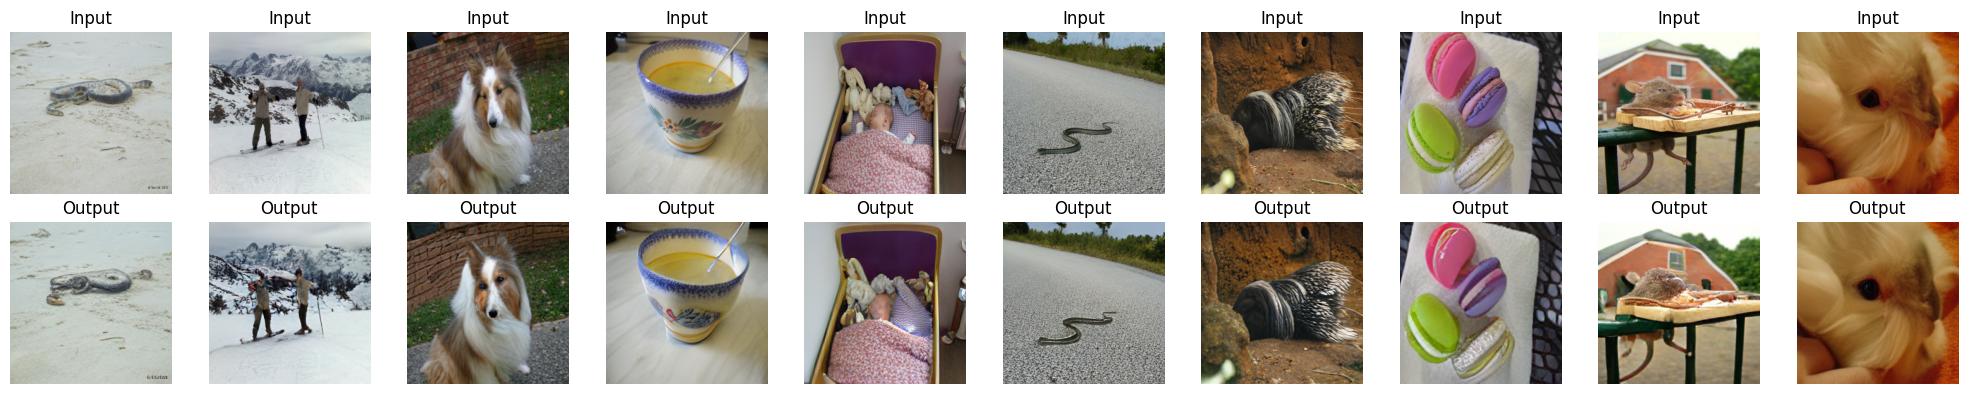

Plot saved to generated_images_plot.png


In [9]:
import matplotlib.pyplot as plt

# Get a batch of images from the dataloader
batch = next(iter(imagenet_dm))
real_imgs, _ = batch  # Assuming batch is (images, labels)
real_imgs = real_imgs[:10].cuda()  # Take the first 10 images

# Forward pass through the model
with torch.no_grad():
    generated_imgs = model(real_imgs)[0]  # Adjust if necessary

# Convert images from [-1, 1] to [0, 1] for visualization
real_imgs = (real_imgs.cpu() * 0.5 + 0.5).clamp(0, 1)
generated_imgs = (generated_imgs.cpu() * 0.5 + 0.5).clamp(0, 1)

# Plot the input and output images
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    # Plot input images (top row)
    axes[0, i].imshow(real_imgs[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[0, i].set_title("Input")

    # Plot output images (bottom row)
    axes[1, i].imshow(generated_imgs[i].permute(1, 2, 0))
    axes[1, i].axis("off")
    axes[1, i].set_title("Output")

plt.tight_layout()

# Save the plot with high resolution
output_path = "generated_images_plot.png"  # Specify your desired file path
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {output_path}")